In [1]:
import os
import sys
import shutil
import time

import numpy as np
from matplotlib import pyplot as plt

plt.rcParams['font.family'] = 'serif'
plt.rcParams['lines.linewidth'] = 1.25


# import dustpy as dp
from dustpy import Simulation
from dustpy import constants as c


print("Done")


Done


In [ ]:
def convert(S, m):
    """Function converts the Dustpy units into number densities.

    Parameters
    ----------
    S : array
        Integrated surface density in DustPy units
    m : array
        mass grid

    Returns
    -------
    Nm2 : array
        Simulation results in desired units for comparison"""
    A = np.mean(m[1:]/m[:-1])
    B = 2 * (A-1) / (A+1)
    return S / B

def solution_constant_kernel(t, m, a, S0):
    """Analytical solution of the constant collision kernel R(m, m') = a.
    Initial condition is that only the zeroth mass bin is filled.

    Parameters
    ----------
    t : float
        Time
    m : Field
        Mass grid
    a : float
        Kernel constant
    S0 : float
        Total dust surface density

    Returns
    -------
    Nm2 : Field
        Analytical solution in desired units."""
    m0 = m[0]
    N0 = S0 / m0
    return N0 / m0 * 4./(a*N0*t)**2 * np.exp( (1.-m/m0) * 2/(a*N0*t) ) * m**2


def setup_simulation(sim, S0):

    # Change dust outer/inner boundary conditions?
    #setcondition()

    # Turning off gas evolution by removing integrator instruction
    del(sim.integrator.instructions[1])
    # Turning off gas source to not influence the time stepping
    sim.gas.S.tot[...] = 0.
    sim.gas.S.tot.updater = None

    # Turning off dust advection
    sim.dust.v.rad[...] = 0.
    sim.dust.v.rad.updater = None

    # sim.dust.v.rel[...] = 0.
    # sim.dust.v.rel.updater = None

    # Setting gas parameters
    sim.gas.Sigma = 1700.
    sim.gas.T = 195. # for v.rel.brown
    sim.gas.alpha = 1e-3

    # Dust scale height
    # sim.dust.H # for coagulation kernel, depends on diffusion terms sim.dust.delta (.rad/turb/vert)

    # Setting the initial time
    sim.t = 1.e-9
    # Setting the initial dust surface density
    m = sim.grid.m
    A = np.mean(m[1:]/m[:-1])
    B = 2 * (A-1) / (A+1)
    sim.dust.Sigma[...] = sim.dust.SigmaFloor[...]
    sim.dust.Sigma[1, :] = np.maximum(solution_constant_kernel(sim.t, m, 1., S0)*B, sim.dust.SigmaFloor[1, :])
    # Updating the simulation object
    sim.update()

In [30]:
# create simulation
sim = Simulation()

# change ini params and initialize simulation
sim.ini.dust.allowDriftingParticles = False
sim.ini.grid.Nr = 3                             # 0D with 2 ghost cells for boundary conditions
sim.ini.grid.Nmbpd = 7
S0 = 1.

sim.initialize()
setup_simulation(sim, S0)

snapshots = np.logspace(-7.,16.,100)
sim.t.snapshots = snapshots

output_dir = "data"

if not os.path.exists(output_dir):
    os.makedirs(output_dir)
shutil.rmtree(output_dir)
sim.writer.datadir = output_dir

sim.run()



DustPy v1.0.9

Documentation: https://stammler.github.io/dustpy/
PyPI:          https://pypi.org/project/dustpy/
GitHub:        https://github.com/stammler/dustpy/

Please cite Stammler & Birnstiel (2022).

Checking for mass conservation...

    - Sticking:
        max. rel. error:  2.82e-14
        for particle collision
            m[114] =  1.93e+04 g    with
            m[116] =  3.73e+04 g
    - Full fragmentation:
        max. rel. error:  5.55e-16
        for particle collision
            m[113] =  1.39e+04 g    with
            m[119] =  1.00e+05 g
    - Erosion:
        max. rel. error:  1.78e-15
        for particle collision
            m[110] =  5.18e+03 g    with
            m[118] =  7.20e+04 g

Creating data directory data.
Writing file data/data0000.hdf5
Writing dump file data/frame.dmp
Writing file data/data0001.hdf5
Writing dump file data/frame.dmp
Writing file data/data0002.hdf5
Writing dump file data/frame.dmp
Writing file data/data0003.hdf5
Writing dump file data

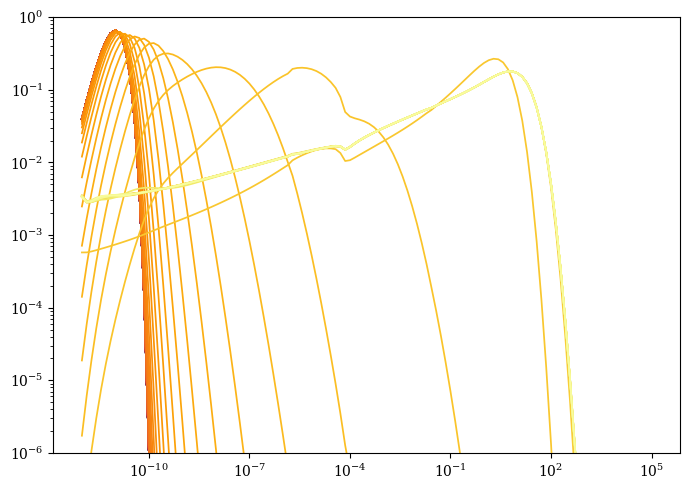

In [31]:
SigmaConstant = sim.writer.read.sequence("dust.Sigma")
m = sim.writer.read.sequence("grid.m")
t = sim.writer.read.sequence("t")



# Plot constant kernel output

fig, ax = plt.subplots(1,1, figsize=(7,5))

ax.loglog(m[0, ...], convert(SigmaConstant[0, 1, :], m[0, ...]), c="black", label="initial (t = 1.0e-09 s)")
ax.plot(0., 0., "-.", c="black", label="analytical", alpha=0.5)

couleurs = plt.cm.inferno(np.linspace(0,1,len(t)+1))
for i in range(1, len(t)):
    cstr = couleurs[i] # "C" + str(i-1)
    ax.loglog(m[i,:], convert(SigmaConstant[i,1,:], m[i,:]), c=cstr, label="t = {:3.1e} s".format(t[i]))
ax.set_ylim(1.e-6, 1.e0)
fig.tight_layout()
# plt.savefig(str(sim.writer.datadir)+"_lowres.png", dpi=300)
plt.show()



In [5]:
# sim.ini.grid
# sim.ini.dust

# sim.grid.m.size # 120
# sim.dust.v.rel.tot.size #43200 = 120 * 120 * 3
# sim.dust.v.rel.tot = 0
# sim.dust.delta
sim.dust.v.rel.tot

[[[2.57616297e-01 2.38882310e-01 2.24435926e-01 ... 7.95735013e+02
   8.88392036e+02 9.91744279e+02]
  [2.38882310e-01 2.18546956e-01 2.02654492e-01 ... 7.95734979e+02
   8.88392003e+02 9.91744247e+02]
  [2.24435926e-01 2.02654492e-01 1.85402758e-01 ... 7.95734944e+02
   8.88391969e+02 9.91744214e+02]
  ...
  [7.95735013e+02 7.95734979e+02 7.95734944e+02 ... 5.87133708e+02
   6.71722882e+02 7.71764961e+02]
  [8.88392036e+02 8.88392003e+02 8.88391969e+02 ... 6.71722882e+02
   6.55173106e+02 7.49558758e+02]
  [9.91744279e+02 9.91744247e+02 9.91744214e+02 ... 7.71764961e+02
   7.49558758e+02 7.31097181e+02]]

 [[1.44868290e-01 1.34344387e-01 1.26261968e-01 ... 5.64632026e+02
   6.46856643e+02 7.50957905e+02]
  [1.34344387e-01 1.22897985e-01 1.13977130e-01 ... 5.64631904e+02
   6.46856532e+02 7.50957805e+02]
  [1.26261968e-01 1.13977130e-01 1.04259633e-01 ... 5.64631769e+02
   6.46856409e+02 7.50957694e+02]
  ...
  [5.64632026e+02 5.64631904e+02 5.64631769e+02 ... 3.08479676e+02
   3.42540